# NO₂ Rate Forecasting in the Lahore Area

## Background

The rapid growth of industrial activity, transportation, and population has led to a significant increase in air pollution levels across many regions. One of the primary air pollutants of concern is Nitrogen Dioxide (NO₂), a toxic gas produced mainly from the combustion of fossil fuels such as motor vehicles, power plants, and industrial activities. NO₂ has serious health impacts, including respiratory problems, lung irritation, and worsening of asthma and bronchitis. In addition, NO₂ contributes to the formation of acid rain and the overall degradation of environmental quality.

This notebook aims to collect, preprocess, and model daily NO₂ time series data for the **Lahore** area using **KNN Regression** to forecast the next day's NO₂ level.

## 1. Data Collection

We will collect daily NO₂ time series data for the Lahore area from the Copernicus Data Space: https://dataspace.copernicus.eu/. Create an account there first.

Documentation for data collection: https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

First, install the `openeo` library:

In [1]:
! pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
! pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.3 MB/s eta 0:00:00


Import the `openeo` library and authenticate:

In [3]:
import openeo

In [4]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=TYCS-EQAH 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


When running the connection line above, you will be asked to authenticate. A link will be printed in the output — click it and log in with your Copernicus account.

Next, define the Area of Interest (AOI) for Lahore and load the Sentinel-5P NO₂ collection. The coordinates below define a bounding polygon around Lahore. You can get coordinates from https://geojson.io by drawing a box over your area of interest.

In [5]:
# Lahore AOI (bounding polygon)

aoi = {
    "type": "Polygon",
    "coordinates": [[
        [74.06287470730837, 31.719248733869478],  # NW
        [74.45290851748351, 31.719248733869478],  # NE
        [74.45290851748351, 31.28668818363299],   # SE
        [74.06287470730837, 31.28668818363299],   # SW
        [74.06287470730837, 31.719248733869478]   # Close polygon
    ]]
}

# Sentinel-5P NO2 data for Lahore

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 74.06287470730837,
        "south": 31.28668818363299,
        "east": 74.45290851748351,
        "north": 31.719248733869478
    },
    bands=["NO2"],
)

# Aggregate to daily means
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Compute mean NO2 over the Lahore AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

Submit the data extraction job. This may take several minutes to complete. Once finished, download the `.nc` file from the OpenEO editor at https://editor.openeo.org.

In [6]:
job = s5post.execute_batch(title="NO2 in Lahore", outputfile="NO2Lahore.nc")

0:00:00 Job 'j-2606030357054f2b9e6103c67fff4cca': send 'start'
0:00:19 Job 'j-2606030357054f2b9e6103c67fff4cca': queued (progress 0%)
0:00:25 Job 'j-2606030357054f2b9e6103c67fff4cca': queued (progress 0%)
0:00:31 Job 'j-2606030357054f2b9e6103c67fff4cca': queued (progress 0%)
0:00:39 Job 'j-2606030357054f2b9e6103c67fff4cca': queued (progress 0%)
0:00:49 Job 'j-2606030357054f2b9e6103c67fff4cca': queued (progress 0%)
0:01:02 Job 'j-2606030357054f2b9e6103c67fff4cca': queued (progress 0%)
0:01:17 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)
0:01:37 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)
0:02:01 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)
0:02:31 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)
0:03:09 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)
0:03:55 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)
0:04:54 Job 'j-2606030357054f2b9e6103c67fff4cca': running (progress N/A)


## 2. Data Preprocessing

After downloading the `.nc` file, we extract just the date and NO₂ columns.

In [7]:
import netCDF4

file_path = "/content/NO2Lahore.nc"
ds = netCDF4.Dataset(file_path)

# View all available variables
print("📦 Variables in file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Extract NO2
no2 = ds.variables["NO2"][:]

# Extract Time
time = ds.variables["t"][:]

# Convert time to date format if 'units' attribute exists
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback if no units attribute

# Display NO2 data structure
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# number of NO2 data records: 725

print(len(no2[0]))
# length of data per row: 9

print(len(no2[0][0]))
# length per data entry: 8

print(no2[0][0][0])
# 3.7701793e-05


📦 Variables in file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
729
13
8
4.4820397e-05


From the code above we can see the structure of the NO₂ data. Each daily record contains a grid of values (rows × columns). Let's view the first 10 records:

In [40]:
'''
print("Sample of first 10 records:")
for i in range(0, 10):
    print(no2[i])
'''

'\nprint("Sample of first 10 records:")\nfor i in range(0, 10):\n    print(no2[i])\n'

Within a single day, there are many NO₂ values across the grid. We will average them so each day has a single value. However, the raw data contains missing values (shown as `--`).

### a. Handling Missing Values using Linear Interpolation

We use linear interpolation to fill missing values across the spatial grid:

In [20]:
import numpy as np
import pandas as pd

# Linear Interpolation to fill missing values
no2_filled = np.zeros_like(no2)
# Safety measure in case '--' masked values don't convert to 0
no2_filled = no2_filled.filled(0)

# Loop over each grid cell (y, x)
for i in range(no2.shape[1]):     # 9 rows
    for j in range(no2.shape[2]): # 8 columns
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()


### b. Average the Data and Convert Datetime

After handling missing values, we average the NO₂ grid per day to get a single value per record. We also convert the datetime format from `2023-10-04 00:00:00` to `2023-10-04` since we only need daily data.

In [21]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # Convert datetime format (e.g., 2023-10-04 00:00:00 → 2023-10-04)
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))


### c. Save Data as CSV

Convert the data into a Pandas DataFrame and save it as a CSV file:

In [22]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Save to CSV
df.to_csv("NO2_Lahore_timeseries.csv", index=False)


### d. Check for Missing Daily Values in the CSV

After saving, verify that the daily time series is complete with no gaps:

In [23]:
df = pd.read_csv("NO2_Lahore_timeseries.csv")

# Ensure 'date' column is datetime type
df['date'] = pd.to_datetime(df['date'])

# Create a complete date range
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Check for missing dates
missing_dates = full_range.difference(df['date'])

print(f"Number of missing days: {len(missing_dates)}")
print("List of missing dates:")
print(missing_dates)


Number of missing days: 2
List of missing dates:
DatetimeIndex(['2024-03-23', '2024-09-24'], dtype='datetime64[ns]', freq=None)


If there are missing days, fix them using linear interpolation on the time index:

In [24]:
# Ensure datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Create a complete date range
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex so missing dates appear as NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Linear interpolation based on time index
df['NO2'] = df['NO2'].interpolate(method='time')

# (Optional) fill any remaining NaN at the edges with forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Save back to CSV
df.to_csv("no2_timeseries_interpolated.csv")


/tmp/ipykernel_10483/585280693.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


### e. Outlier Detection using IQR

After filling missing values, we detect outliers using the Interquartile Range (IQR) method:

In [25]:
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Calculate IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Number of Outliers (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())


Number of Outliers (IQR): 44
         date       NO2
46 2023-11-16  0.000206
71 2023-12-11  0.000166
74 2023-12-14  0.000160
82 2023-12-22  0.000213
86 2023-12-26  0.000231


Visualize the outliers:

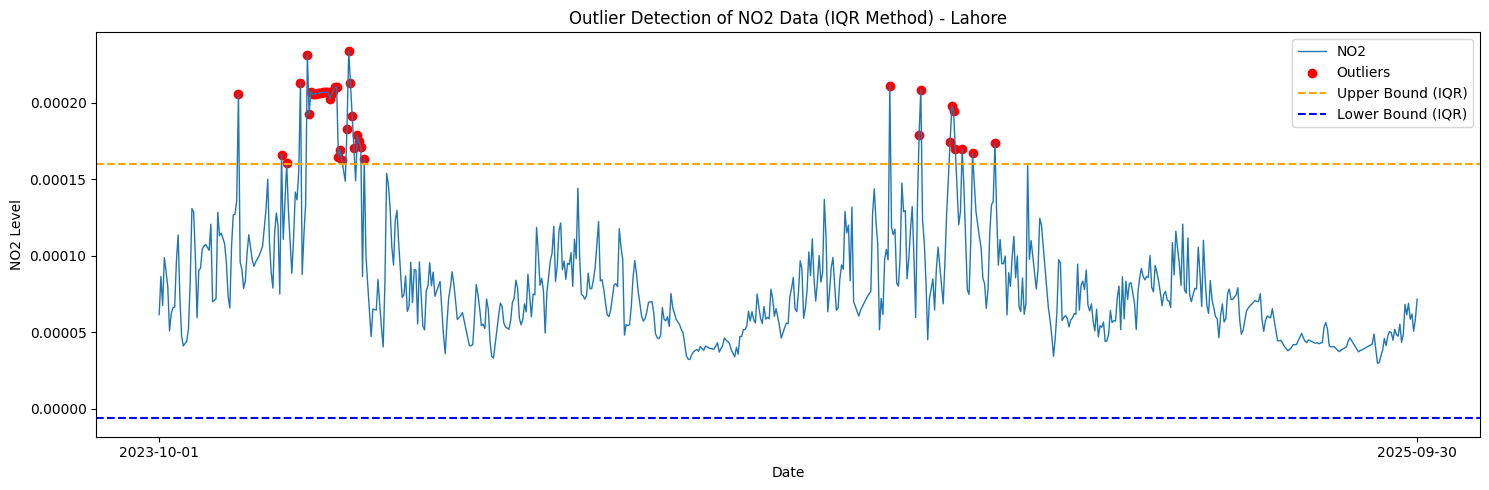

In [26]:
# === Visualization ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Outlier points
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Upper and lower bound lines
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Outlier Detection of NO2 Data (IQR Method) - Lahore")
plt.xlabel("Date")
plt.ylabel("NO2 Level")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()


Since this is time series data, detected outliers are not simply removed — they are replaced using linear interpolation to maintain the continuity of the series:

In [27]:
# Mark outliers as NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Number of values marked as outliers:", df['NO2_cleaned'].isna().sum())

# Linear interpolation to fill outlier positions
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Fill any remaining NaN at the edges with forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

print("Missing values after interpolation:", df['NO2_filled'].isna().sum())


Number of values marked as outliers: 44
Missing values after interpolation: 0


Visualize the data after outlier removal and interpolation:

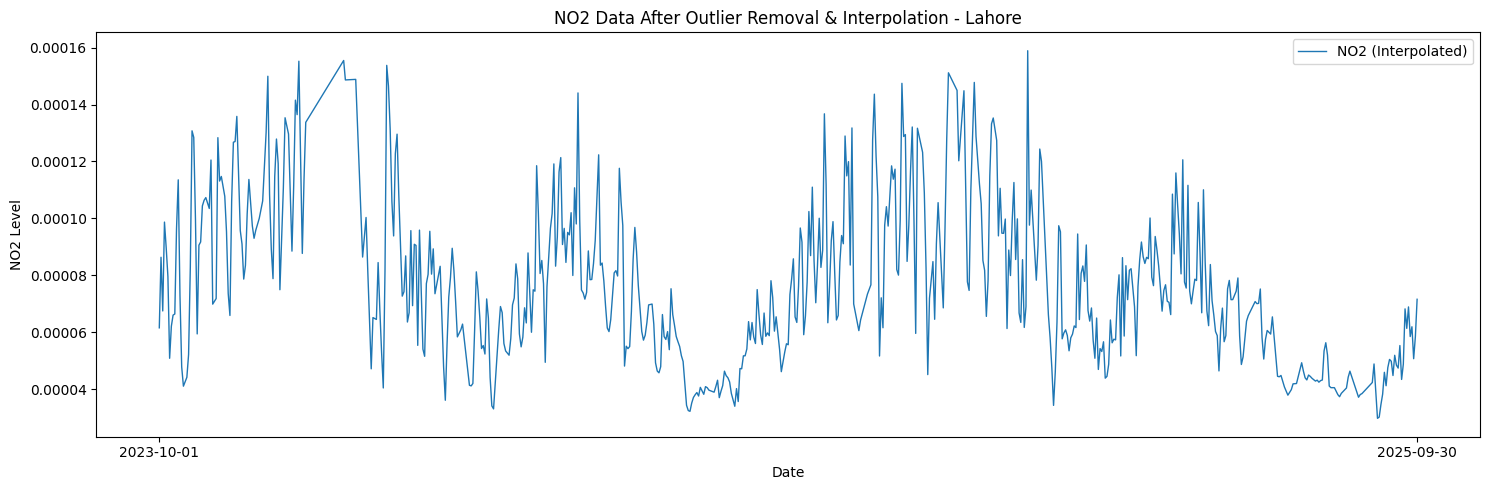

In [28]:
plt.figure(figsize=(15,5))
# Plot interpolated data
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Show only first and last dates on X axis
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("NO2 Data After Outlier Removal & Interpolation - Lahore")
plt.xlabel("Date")
plt.ylabel("NO2 Level")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Modeling using KNN Regression

Using the daily NO₂ time series data for Lahore, we will predict the NO₂ level for the next day. We transform the data into a supervised learning format by using previous days as features.

### a. Correlation Analysis

Before modeling, we convert the unsupervised time series into a supervised format and test the correlation between lag features (t-1, t-2, ..., t-30) and the target (t). This helps us choose the best number of lag days as features:

In [29]:
def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Create lag features from t-n to t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Target for day t
    df_supervised['NO2(t)'] = data

    # Remove rows with NaN caused by shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# Example usage
supervised_df30 = create_supervised(df['NO2'], n_lag=30)

# Get all lag columns and target column
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Display correlation values
print(correlations)


NO2(t-30)    0.368882
NO2(t-29)    0.401345
NO2(t-28)    0.413989
NO2(t-27)    0.434001
NO2(t-26)    0.459660
NO2(t-25)    0.487574
NO2(t-24)    0.492218
NO2(t-23)    0.497640
NO2(t-22)    0.495375
NO2(t-21)    0.498271
NO2(t-20)    0.505823
NO2(t-19)    0.542957
NO2(t-18)    0.558504
NO2(t-17)    0.570016
NO2(t-16)    0.577754
NO2(t-15)    0.567789
NO2(t-14)    0.568322
NO2(t-13)    0.580838
NO2(t-12)    0.594876
NO2(t-11)    0.622060
NO2(t-10)    0.637956
NO2(t-9)     0.647031
NO2(t-8)     0.652389
NO2(t-7)     0.665431
NO2(t-6)     0.668177
NO2(t-5)     0.668497
NO2(t-4)     0.679162
NO2(t-3)     0.706149
NO2(t-2)     0.770848
NO2(t-1)     0.853985
dtype: float64


Correlation values range from -1 to 1. We select lag features with a correlation greater than 0.5 as the best predictors (typically t-1 to t-4).

### b. Data Normalization

Since we use KNN Regression, we normalize the data to the 0–1 range using Min-Max Scaler:

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

### c. Transform Data into Supervised Format

We create supervised datasets using 4 and 10 lag days, based on the correlation analysis:

In [33]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.155807  0.277253  0.184863  0.337817  0.293836
5    0.277253  0.184863  0.337817  0.293836  0.244083
6    0.184863  0.337817  0.293836  0.244083  0.103377
7    0.337817  0.293836  0.244083  0.103377  0.158555
8    0.293836  0.244083  0.103377  0.158555  0.177693
..        ...       ...       ...       ...       ...
726  0.093296  0.188410  0.154885  0.191788  0.140827
727  0.188410  0.154885  0.191788  0.140827  0.157651
728  0.154885  0.191788  0.140827  0.157651  0.102658
729  0.191788  0.140827  0.157651  0.102658  0.140999
730  0.140827  0.157651  0.102658  0.140999  0.204933

[727 rows x 5 columns]
(727, 5)


In [34]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.155807  0.277253  0.184863  0.337817  0.293836  0.244083  0.103377   
11    0.277253  0.184863  0.337817  0.293836  0.244083  0.103377  0.158555   
12    0.184863  0.337817  0.293836  0.244083  0.103377  0.158555  0.177693   
13    0.337817  0.293836  0.244083  0.103377  0.158555  0.177693  0.179588   
14    0.293836  0.244083  0.103377  0.158555  0.177693  0.179588  0.326424   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.073710  0.108529  0.091480  0.086498  0.125299  0.066967  0.093296   
727   0.108529  0.091480  0.086498  0.125299  0.066967  0.093296  0.188410   
728   0.091480  0.086498  0.125299  0.066967  0.093296  0.188410  0.154885   
729   0.086498  0.125299  0.066967  0.093296  0.188410  0.154885  0.191788   
730   0.125299  0.066967  0.093296  0.188410  0.154885  0.191788  0.140827   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.158555  0.

### d. Modeling and Evaluation

We train a KNN Regression model on both datasets (4-day and 10-day lag) using an 80/20 train-test split:

In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Separate features and label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # KNN Model
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Predict
    y_pred = knn.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model with 4 previous days
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Previous Days")

# Train model with 10 previous days
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Previous Days")



=== KNN - 4 Previous Days ===
Train Size: 581 — Test Size: 146
RMSE: 0.069103
R² Score: 0.4268
MAPE: 42.4262%

=== KNN - 10 Previous Days ===
Train Size: 576 — Test Size: 145
RMSE: 0.054943
R² Score: 0.6387
MAPE: 41.8936%


We also test with 30 previous days to compare whether more lag days improve the model:

In [36]:
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Previous Days")



=== KNN - 30 Previous Days ===
Train Size: 560 — Test Size: 141
RMSE: 0.000012
R² Score: 0.5372
MAPE: 16.4198%


### e. Plotting

Visualization of actual vs predicted NO₂ values for each lag configuration.

**4 previous days:**

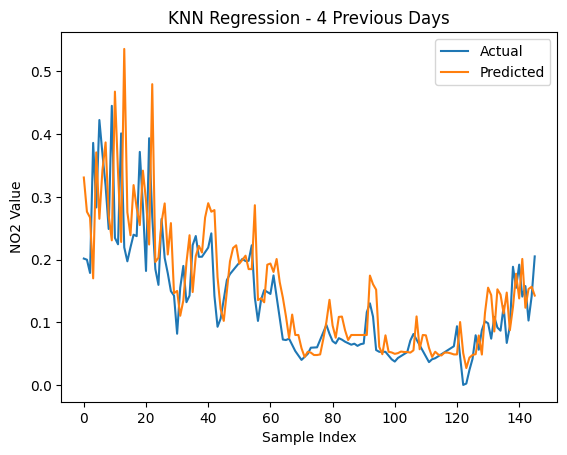

In [37]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Previous Days")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()


**10 previous days:**

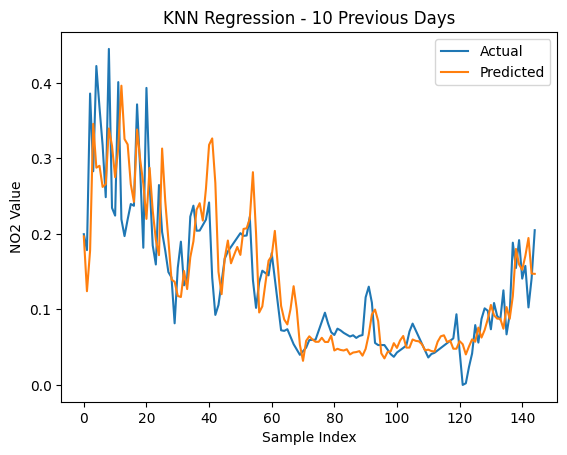

In [38]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Previous Days")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()


**30 previous days:**

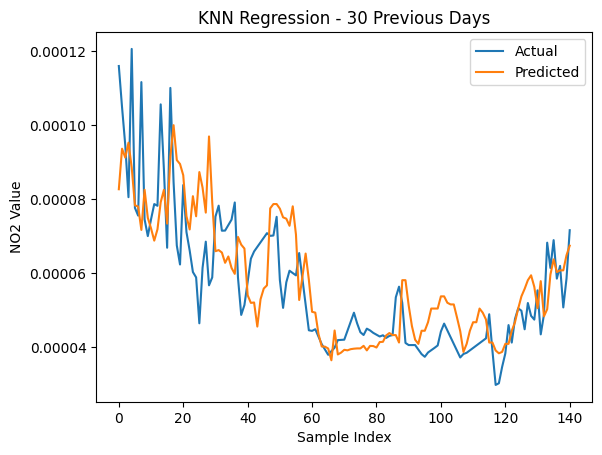

In [39]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Previous Days")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()


## Conclusion

The KNN Regression evaluation results show that increasing the number of historical lag features does not necessarily improve prediction performance. The 4-day lag model achieves the lowest RMSE and a positive R² score, meaning the model can explain some variability in the target data. However, when the lag is extended to 10 and 30 days, performance declines — RMSE and MAPE increase, and R² drops to negative values at 30 lags.

The high MAPE values across all models (above 60%) indicate that prediction accuracy is still low and there is significant deviation between predicted and actual values. Overall, KNN does not perform well on this dataset, and adding more lag features leads to overfitting and reduced generalization. Therefore, alternative models or improved preprocessing strategies may be needed to achieve better forecasting results.